# Set Environment

In [1]:
## textstat is used for readability scoring.
!pip install vaderSentiment -q
!pip install lingua-language-detector deep-translator -q
!pip install wordcloud scikit-learn -q
!pip install thefuzz python-Levenshtein -q
!pip install textstat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.0 MB/s eta 0:00:00


In [2]:
# Install all required libraries before importing anything.

from google.colab import drive
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from importlib import reload
import textstat
import re

drive.mount('/content/drive', force_remount=True)

BASE_DIR   = '/content/drive/Shareddrives/essentis_intern_drive'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
SRC_DIR    = os.path.join(DATA_DIR, 'src_reviews_cleaning')
CHARTS_DIR = os.path.join(BASE_DIR, 'charts', 'student_experience')
EXPORT_DIR = os.path.join(BASE_DIR, 'charts', 'student_experience', 'exports')

if DATA_DIR not in sys.path:
    sys.path.insert(0, DATA_DIR)

os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)

sns.set_theme()

print("Setup complete.")
print("SRC_DIR exists:  ", os.path.exists(SRC_DIR))
print("CHARTS_DIR:      ", CHARTS_DIR)
print("EXPORT_DIR:      ", EXPORT_DIR)

Mounted at /content/drive
Setup complete.
SRC_DIR exists:   True
CHARTS_DIR:       /content/drive/Shareddrives/essentis_intern_drive/charts/student_experience
EXPORT_DIR:       /content/drive/Shareddrives/essentis_intern_drive/charts/student_experience/exports


# Load Data

In [3]:
# Load cleaned data from the pipeline and prepare the text column used
# throughout this notebook. Translated text is used for non-English reviews
# so all downstream analysis runs on English text only.
# It will take some time to run the pipeline!

import src_reviews_cleaning.pipeline as P
reload(P)

df = P.run(save_csv=False)

df['text_for_analysis'] = df['review_text_translated'].where(
    df['review_text_translated'].notna(), df['review_text']
)

df = df.dropna(subset=['text_for_analysis']).reset_index(drop=True)
df['text_lower'] = df['text_for_analysis'].str.lower()

# Run VADER on all reviews upfront so sentiment columns are available
# to every analysis cell without repeating the scoring step.
analyzer = SentimentIntensityAnalyzer()
scores = df['text_for_analysis'].apply(lambda x: analyzer.polarity_scores(str(x)))
df['sentiment_compound'] = scores.apply(lambda x: x['compound'])
df['sentiment_label']    = df['sentiment_compound'].apply(
    lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
)

# Calculate review length in characters and words for later cells
df['review_length_chars'] = df['text_for_analysis'].str.len()
df['review_length_words'] = df['text_for_analysis'].str.split().str.len()

print("Shape:", df.shape)
print("\nSentiment breakdown:")
print(df['sentiment_label'].value_counts())

Step 1/4: Loading raw data...
  google: 256 rows
  clean: 541 rows
  new: 49 rows
Step 2/4: Normalizing columns...


/content/drive/Shareddrives/essentis_intern_drive/data/src_reviews_cleaning/normalizers.py:297: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(normalized, ignore_index=True)


  Combined shape: (846, 17)
Step 3/4: Cleaning data (includes language detection + translation)...
  [17/846] Translated from FRENCH: Très bonne école de formation. Les cours sont bien...
  [206/846] Translated from GERMAN: Der KI Kompaktkurs bei WBS Coding School bietet ei...
  [207/846] Translated from GERMAN: Abhängig vom eigenen Skillset und der jeweiligen G...
  [208/846] Translated from GERMAN: Der AI Compact-Kurs war ausgezeichnet. Er hat mir ...
  [209/846] Translated from GERMAN: Von Mai bis Juli 2025 habe ich an der WBS eine Wei...
  [210/846] Translated from GERMAN: Das Bootcamp "AI for Business" war für mich ein ec...
  [211/846] Translated from GERMAN: Ich habe den Data Science-Kurs abgeschlossen und e...
  [212/846] Translated from GERMAN: Anfangs war ich unsicher, ob mein Vorwissen für da...
  [213/846] Translated from GERMAN: Ich bin mit wenig Programmier-Erfahrung ins Data S...
  [214/846] Translated from GERMAN: Ich habe in den letzten 8 Wochen am KI-Kurs der WB...
  

# Review length vs. Sentiment

Median length (positive): 494 characters
Median length (neutral): 193 characters
Median length (negative): 236 characters


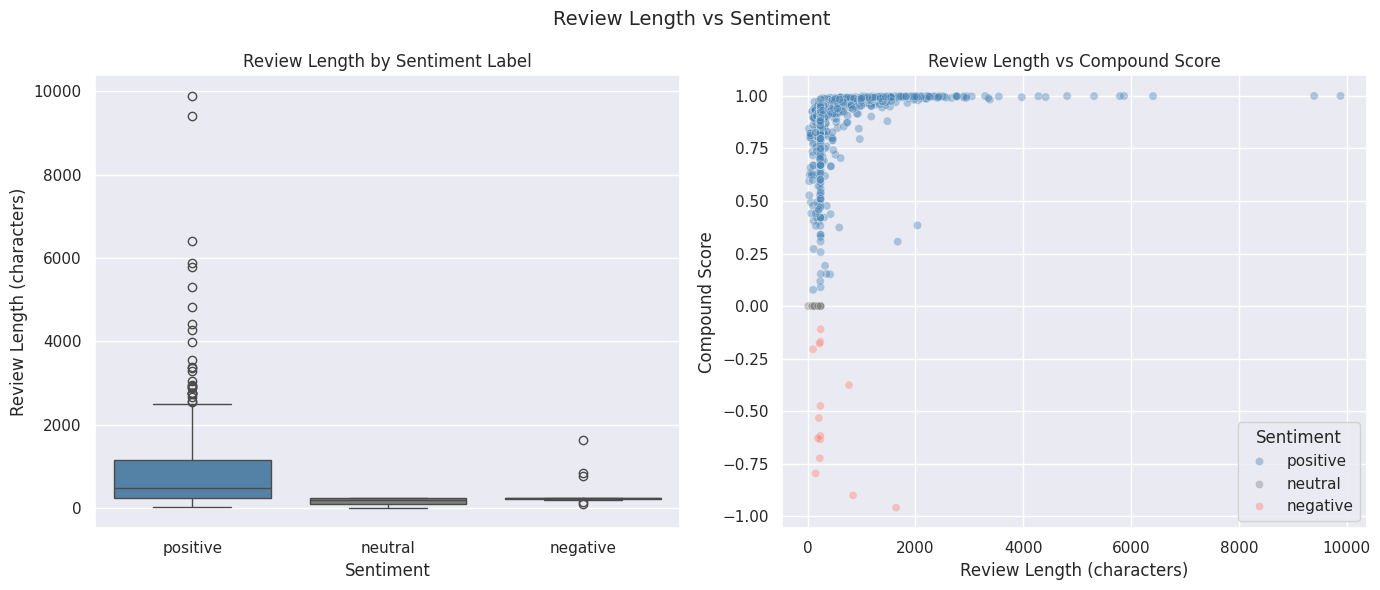

Saved: review_length_vs_sentiment.png


In [4]:
# Investigate whether longer reviews tend to be more negative.
# A common pattern in review datasets is that dissatisfied customers write
# more because they feel compelled to explain what went wrong.
# Two charts: box plot of length by sentiment, scatter of length vs score.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Review Length vs Sentiment", fontsize=14)

palette     = {'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'}
label_order = ['positive', 'neutral', 'negative']

sns.boxplot(
    data=df, x='sentiment_label', y='review_length_chars',
    hue='sentiment_label', legend=False,
    order=label_order, palette=palette, ax=axes[0]
)
axes[0].set_title("Review Length by Sentiment Label")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Review Length (characters)")

for label in label_order:
    median = df[df['sentiment_label'] == label]['review_length_chars'].median()
    print(f"Median length ({label}): {int(median)} characters")

sns.scatterplot(
    data=df, x='review_length_chars', y='sentiment_compound',
    hue='sentiment_label', palette=palette,
    alpha=0.4, ax=axes[1]
)
axes[1].set_title("Review Length vs Compound Score")
axes[1].set_xlabel("Review Length (characters)")
axes[1].set_ylabel("Compound Score")
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'review_length_vs_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: review_length_vs_sentiment.png")

# Platform vs. Sentiment

Sample sizes per platform:
source
switchup         317
course_report    266
google           235


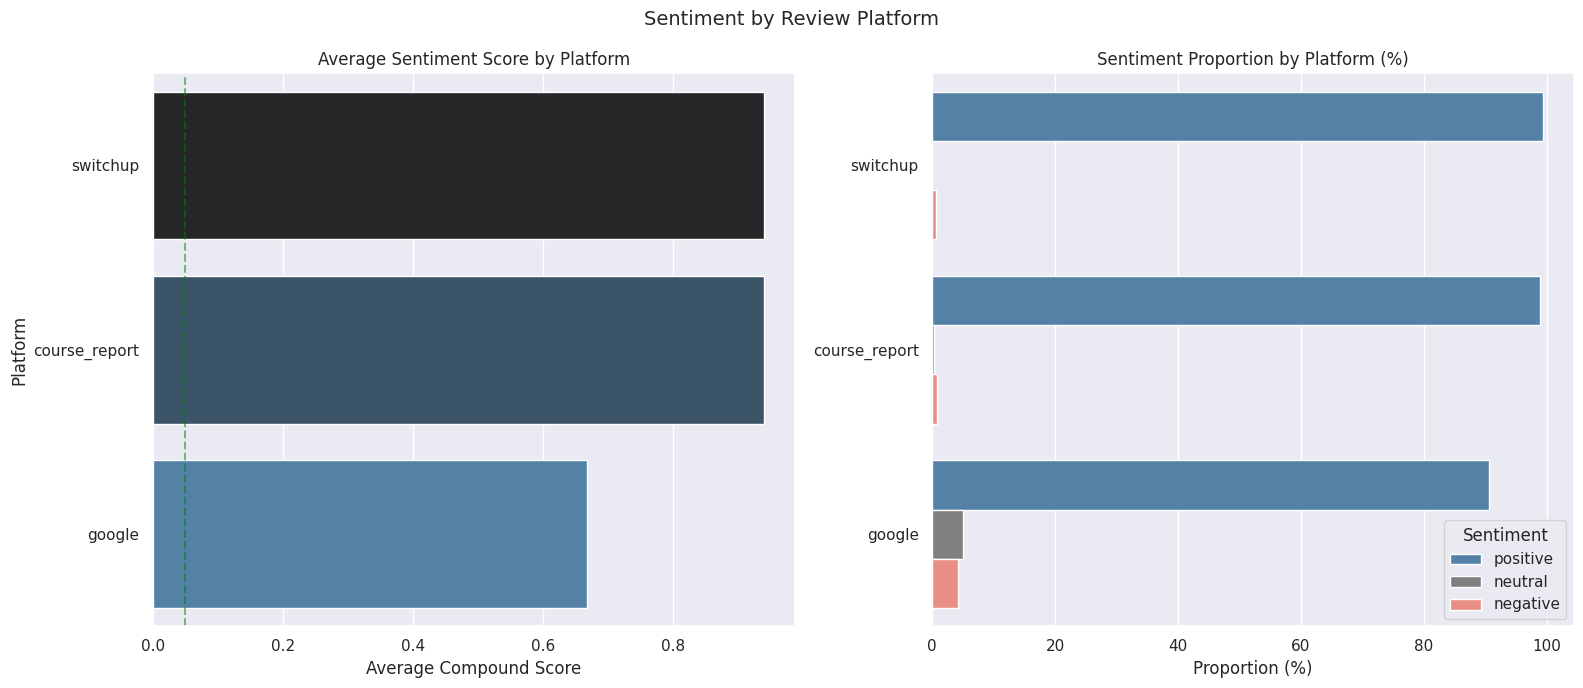

Saved: sentiment_by_platform.png


In [5]:
# Compare sentiment across review platforms.
# Students who review on Google may write differently from those on Course
# Report or SwitchUp. Platform bias affects where social proof is most
# credible and where marketing spend is best directed.
# Only platforms with at least 5 reviews are included.

source_df     = df.dropna(subset=['source']).copy()
valid_sources = source_df['source'].value_counts()
valid_sources = valid_sources[valid_sources >= 5].index
source_df     = source_df[source_df['source'].isin(valid_sources)]

source_order = (
    source_df.groupby('source')['sentiment_compound']
    .mean().sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Sentiment by Review Platform", fontsize=14)

avg_source = source_df.groupby('source')['sentiment_compound'].mean().reset_index()
avg_source.columns = ['source', 'avg_compound']
avg_source = avg_source.sort_values('avg_compound', ascending=False)
sns.barplot(
    data=avg_source, x='avg_compound', y='source',
    hue='source', legend=False,
    ax=axes[0], palette='dark:steelblue'
)
axes[0].axvline(0.05, color='green', linestyle='--', alpha=0.5)
axes[0].set_title("Average Sentiment Score by Platform")
axes[0].set_xlabel("Average Compound Score")
axes[0].set_ylabel("Platform")

label_data = source_df.groupby(['source', 'sentiment_label']).size().reset_index(name='count')
total_data  = source_df.groupby('source').size().reset_index(name='total')
label_data  = label_data.merge(total_data, on='source')
label_data['proportion'] = (label_data['count'] / label_data['total'] * 100).round(1)
label_data['sentiment_label'] = pd.Categorical(
    label_data['sentiment_label'],
    categories=['positive', 'neutral', 'negative'], ordered=True
)
sns.barplot(
    data=label_data, x='proportion', y='source',
    hue='sentiment_label', order=source_order,
    palette={'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'},
    ax=axes[1]
)
axes[1].set_title("Sentiment Proportion by Platform (%)")
axes[1].set_xlabel("Proportion (%)")
axes[1].set_ylabel("")
axes[1].legend(title='Sentiment')

print("Sample sizes per platform:")
print(source_df['source'].value_counts().to_string())

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sentiment_by_platform.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sentiment_by_platform.png")

# Verification vs. Sentiment

Summary statistics:

  Verified (n=391)
    Mean compound:   0.946
    Pct positive:    99.5%

  Unverified (n=145)
    Mean compound:   0.915
    Pct positive:    97.9%


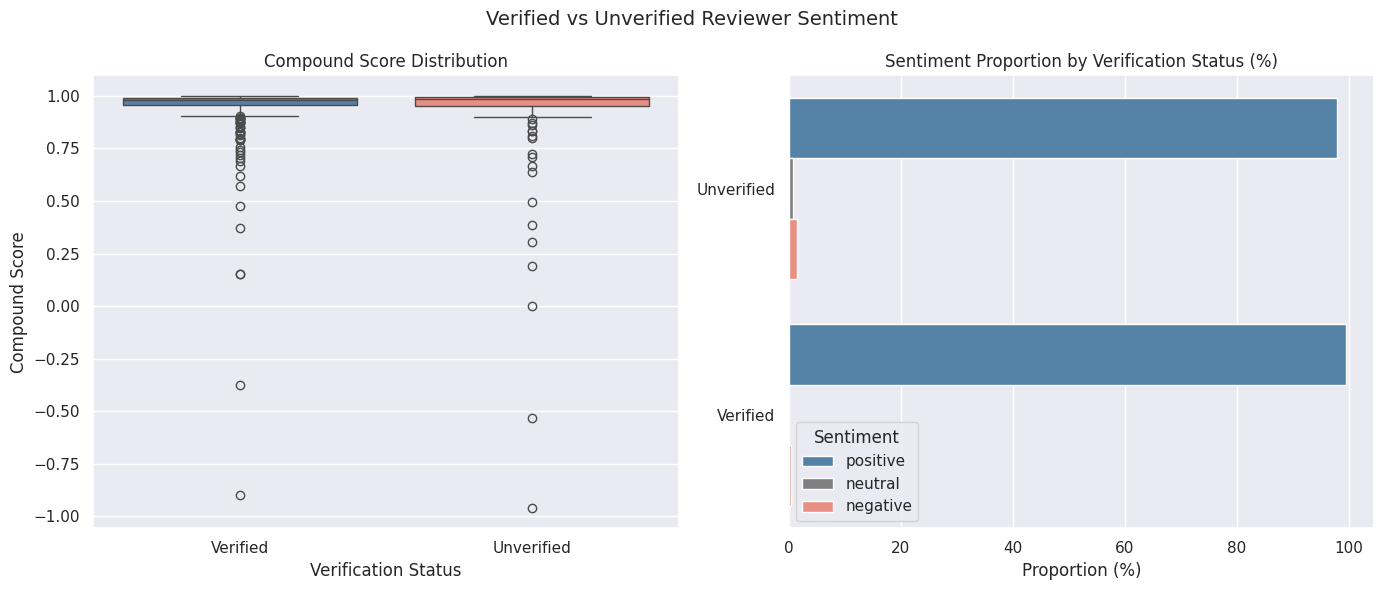

Saved: verified_vs_unverified.png


In [6]:
# Compare sentiment between verified and unverified reviewers.
# Verified reviewers have had their identity confirmed by a third party.
# If unverified reviewers skew more negative it may suggest anonymous
# reviewers feel less accountable and more willing to criticize.
# Google reviews have no verification data and are excluded here.

verified_df = df.dropna(subset=['verified']).copy()
verified_df['verified_label'] = verified_df['verified'].map(
    {True: 'Verified', False: 'Unverified'}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Verified vs Unverified Reviewer Sentiment", fontsize=14)

sns.boxplot(
    data=verified_df, x='verified_label', y='sentiment_compound',
    hue='verified_label', legend=False,
    ax=axes[0], palette={'Verified': 'steelblue', 'Unverified': 'salmon'}
)
axes[0].set_title("Compound Score Distribution")
axes[0].set_xlabel("Verification Status")
axes[0].set_ylabel("Compound Score")

label_data = verified_df.groupby(['verified_label', 'sentiment_label']).size().reset_index(name='count')
total_data  = verified_df.groupby('verified_label').size().reset_index(name='total')
label_data  = label_data.merge(total_data, on='verified_label')
label_data['proportion'] = (label_data['count'] / label_data['total'] * 100).round(1)
label_data['sentiment_label'] = pd.Categorical(
    label_data['sentiment_label'],
    categories=['positive', 'neutral', 'negative'], ordered=True
)
sns.barplot(
    data=label_data, x='proportion', y='verified_label',
    hue='sentiment_label',
    palette={'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'},
    ax=axes[1]
)
axes[1].set_title("Sentiment Proportion by Verification Status (%)")
axes[1].set_xlabel("Proportion (%)")
axes[1].set_ylabel("")
axes[1].legend(title='Sentiment')

print("Summary statistics:")
for label in ['Verified', 'Unverified']:
    subset = verified_df[verified_df['verified_label'] == label]
    print(f"\n  {label} (n={len(subset)})")
    print(f"    Mean compound:   {subset['sentiment_compound'].mean():.3f}")
    print(f"    Pct positive:    {(subset['sentiment_label'] == 'positive').mean() * 100:.1f}%")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'verified_vs_unverified.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: verified_vs_unverified.png")

# Motivation Detection

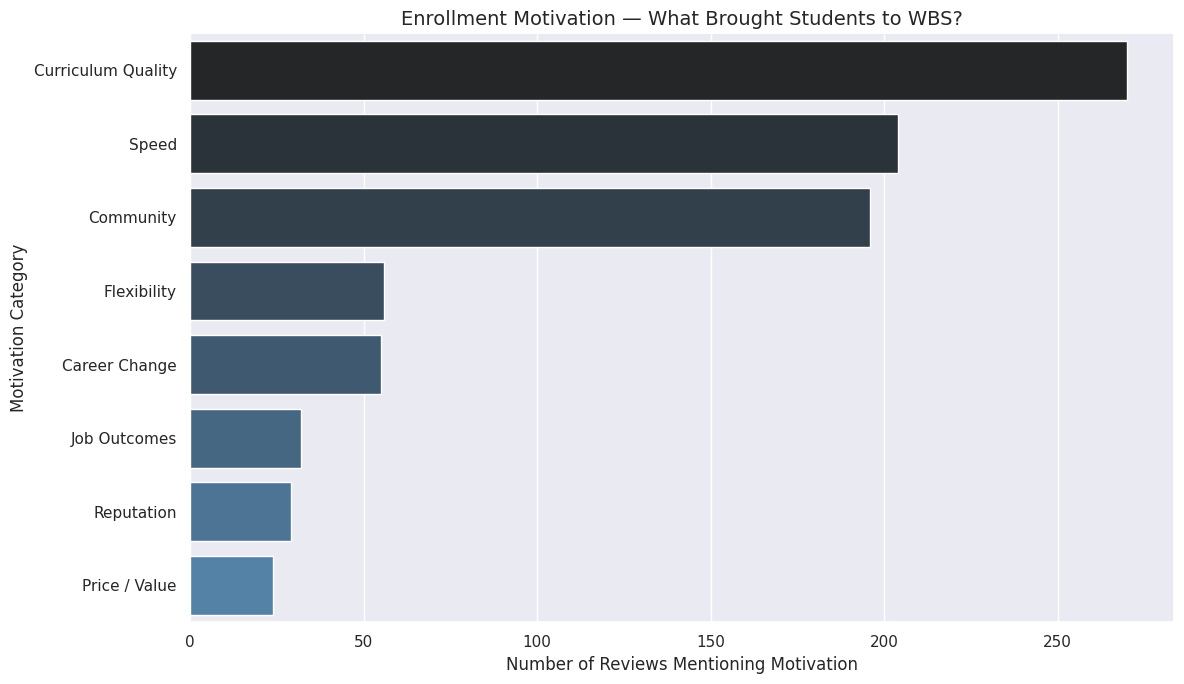

Saved: enrollment_motivation.png

Motivation mention counts:
        motivation  count
Curriculum Quality    270
             Speed    204
         Community    196
       Flexibility     56
     Career Change     55
      Job Outcomes     32
        Reputation     29
     Price / Value     24


In [7]:
# Detect why students chose WBS by looking for motivation keywords.
# Understanding what drives enrollment decisions is valuable for marketing
# because it reveals what WBS is actually competing on in students' minds.

MOTIVATION_KEYWORDS = {
    "Career Change":      ["career change", "career switch", "new career", "transition",
                           "change my life", "pivot"],
    "Job Outcomes":       ["get a job", "find a job", "hired", "employment",
                           "job ready", "placement"],
    "Curriculum Quality": ["curriculum", "up to date", "modern", "relevant",
                           "practical", "hands on", "project based"],
    "Flexibility":        ["flexible", "part time", "part-time", "remote",
                           "work while", "balance"],
    "Reputation":         ["reputation", "recommended", "heard about",
                           "word of mouth", "known for"],
    "Price / Value":      ["affordable", "price", "cost", "cheaper",
                           "worth the money", "investment", "scholarship"],
    "Community":          ["community", "network", "peers", "cohort",
                           "not alone", "support network"],
    "Speed":              ["fast", "intensive", "short time",
                           "quickly", "few months", "15 weeks"],
}

for category, keywords in MOTIVATION_KEYWORDS.items():
    df[f'motivation_{category}'] = df['text_lower'].apply(
        lambda text: any(kw in str(text) for kw in keywords)
    )

motivation_counts = {
    cat: df[f'motivation_{cat}'].sum()
    for cat in MOTIVATION_KEYWORDS
}
motivation_df = pd.DataFrame(
    list(motivation_counts.items()),
    columns=['motivation', 'count']
).sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=motivation_df, x='count', y='motivation',
    hue='motivation', legend=False,
    ax=ax, palette='dark:steelblue'
)
ax.set_title("Enrollment Motivation — What Brought Students to WBS?", fontsize=14)
ax.set_xlabel("Number of Reviews Mentioning Motivation")
ax.set_ylabel("Motivation Category")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'enrollment_motivation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: enrollment_motivation.png")
print("\nMotivation mention counts:")
print(motivation_df.to_string(index=False))

# Expectations vs. Experience

Reviews where reality exceeded expectations: 44
Reviews where reality fell short:            15


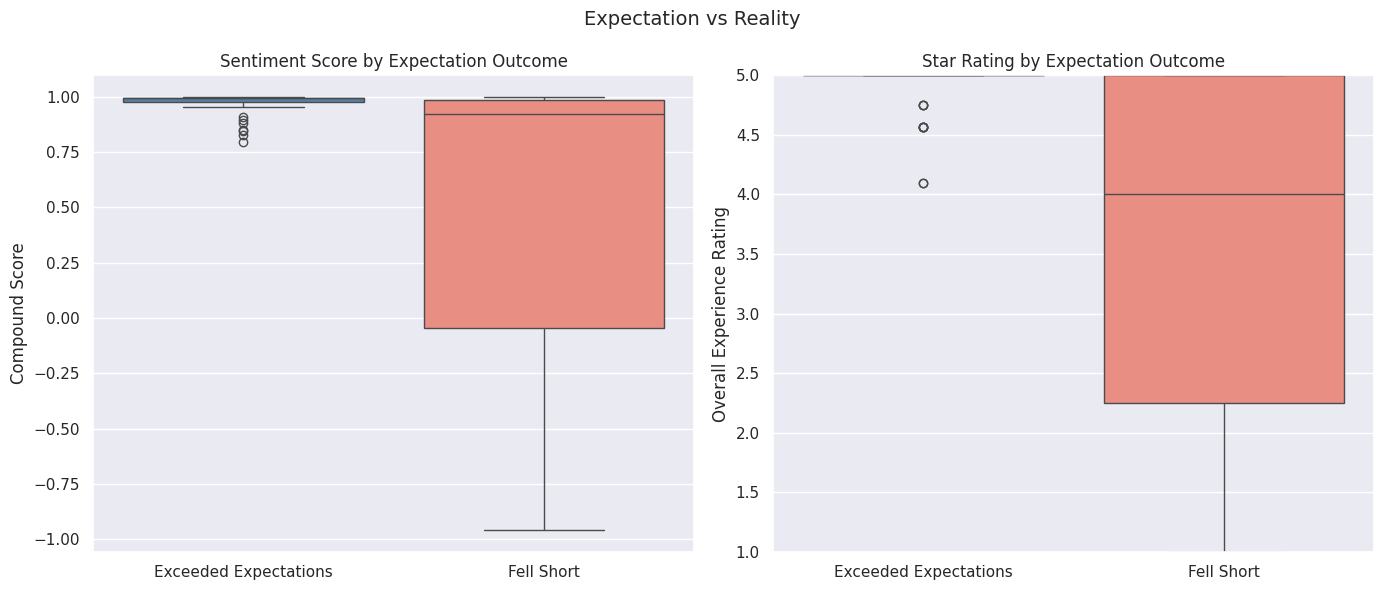

Saved: expectation_vs_reality.png

Sample reviews where expectations were exceeded:

  Haniyeh Ebrahimi Salari  | Data Science
  A Transformative Experience at WBS Coding School: Blending Tech Skills and Soft Skills: I recently had the privilege of completing the Data Science Boot Camp at the WBS Coding School, and I can confid

  Amir Juya | Full-Stack Web & App
  "Fantastic Experience at WBS Coding School": I recently completed the Full-Stack Web & App Development (full-time) bootcamp at WBS Coding School, and I can't speak highly enough about the experience,.

  Hanne  | Data Science
  great learning experience: just finished the full time Data Science Bootcamp and it exceeded my expectations by far. I learned much more than I thought in the last 17 weeks. The materials and the proj

Sample reviews where expectations fell short:

  Anonymous | Full-Stack Web & App
  Unfortunately disappointed overall: I attended online bootcamp full time. Unfortunately, I haven't had a good experien

In [8]:
# Identify reviews that explicitly compare expectations to actual experience.
# These are valuable because they reveal where WBS marketing is setting
# accurate expectations and where it may be over-promising or under-delivering.
# Reviews are split into those where reality exceeded expectations
# and those where it fell short.

EXCEED_KEYWORDS = [
    "exceeded", "surpassed", "better than expected", "more than i expected",
    "pleasantly surprised", "beyond what i expected", "blown away",
]

FELL_SHORT_KEYWORDS = [
    "disappointed", "not what i expected", "expected more", "fell short",
    "not as good", "overpromised", "misleading", "not worth",
    "regret", "waste of money", "waste of time",
]

df['expectation_exceeded']  = df['text_lower'].apply(
    lambda x: any(kw in str(x) for kw in EXCEED_KEYWORDS)
)
df['expectation_fell_short'] = df['text_lower'].apply(
    lambda x: any(kw in str(x) for kw in FELL_SHORT_KEYWORDS)
)

exceeded   = df[df['expectation_exceeded']].copy()
fell_short = df[df['expectation_fell_short']].copy()

print(f"Reviews where reality exceeded expectations: {len(exceeded)}")
print(f"Reviews where reality fell short:            {len(fell_short)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Expectation vs Reality", fontsize=14)

# Compare compound scores between exceeded and fell short groups
expect_compare = pd.concat([
    exceeded.assign(group='Exceeded Expectations'),
    fell_short.assign(group='Fell Short'),
])
sns.boxplot(
    data=expect_compare, x='group', y='sentiment_compound',
    hue='group', legend=False,
    ax=axes[0], palette={'Exceeded Expectations': 'steelblue', 'Fell Short': 'salmon'}
)
axes[0].set_title("Sentiment Score by Expectation Outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("Compound Score")

# Compare overall experience rating between the two groups
sns.boxplot(
    data=expect_compare, x='group', y='overall_experience',
    hue='group', legend=False,
    ax=axes[1], palette={'Exceeded Expectations': 'steelblue', 'Fell Short': 'salmon'}
)
axes[1].set_title("Star Rating by Expectation Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Overall Experience Rating")
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'expectation_vs_reality.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: expectation_vs_reality.png")

print("\nSample reviews where expectations were exceeded:")
for i, row in exceeded.nlargest(3, 'sentiment_compound').iterrows():
    print(f"\n  {row['author']} | {row['course']}")
    print(f"  {str(row['text_for_analysis'])[:200]}")

print("\nSample reviews where expectations fell short:")
for i, row in fell_short.nsmallest(3, 'sentiment_compound').iterrows():
    print(f"\n  {row['author']} | {row['course']}")
    print(f"  {str(row['text_for_analysis'])[:200]}")

# Hiring Mentions

Reviews mentioning job outcomes: 17
Reviews not mentioning jobs:     801

  Hired (n=17)
    Mean compound: 0.937
    Mean rating:   4.69

  Not mentioned (n=801)
    Mean compound: 0.860
    Mean rating:   4.78


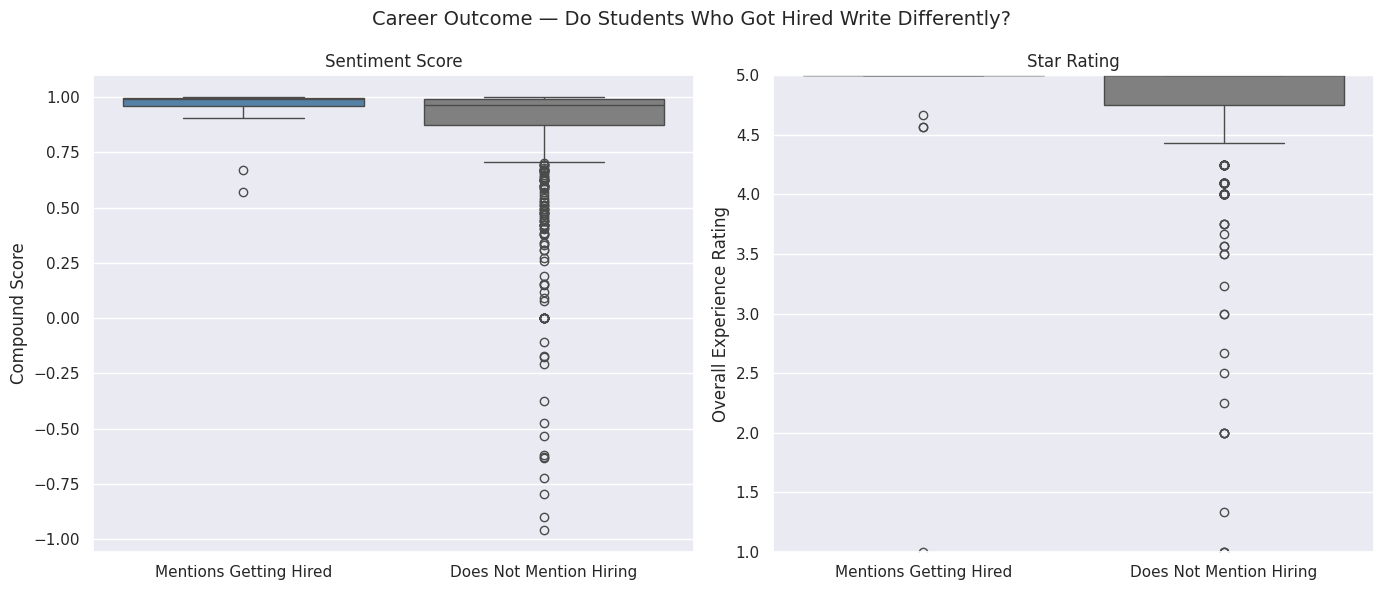

Saved: career_outcome_tracking.png

Sample reviews mentioning getting hired:

  Imogen Drews  | Full-Stack Web & App
  Great full-stack development course: My overall experience at WBS Coding School was great and I would recommend this course to other aspiring web developers out there. I entered this course as a complete beginner, not even knowing what a terminal was

  Imogen Drews | Full-Stack Web & App
  "Great Full-Stack Course": My overall experience at WBS was great and I would recommend this course to other aspiring web developers out there. I entered this course as a complete beginner, not even knowing what a terminal was or what the difference 

  Stephan Eckart  | Full-Stack Web & App
  Amazing but intense start in a new future: I'm immensely grateful for the transformative experience the WBS Full Stack Development program provided. The dedicated instructors, well-rounded curriculum, and strong sense of community have equipped me fo


In [9]:
# Identify reviews where students mention getting hired after the course.
# Students who mention job outcomes may write with more gratitude and
# enthusiasm than those who do not, reflecting the course's impact on
# their lives beyond just the learning experience.
# This is also useful for validating the job placement story in marketing.

HIRED_KEYWORDS = [
    "got a job", "found a job", "landed a job", "got hired", "been hired",
    "got an offer", "job offer", "employed", "working as", "now work",
    "currently work", "full time job", "full-time job", "started working",
    "new job", "new role", "new position",
]

df['mentions_hiring'] = df['text_lower'].apply(
    lambda x: any(kw in str(x) for kw in HIRED_KEYWORDS)
)

hired_df     = df[df['mentions_hiring']].copy()
not_hired_df = df[~df['mentions_hiring']].copy()

print(f"Reviews mentioning job outcomes: {len(hired_df)}")
print(f"Reviews not mentioning jobs:     {len(not_hired_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Career Outcome — Do Students Who Got Hired Write Differently?", fontsize=14)

# Compare compound scores between hired and not-hired groups
outcome_compare = pd.concat([
    hired_df.assign(group='Mentions Getting Hired'),
    not_hired_df.assign(group='Does Not Mention Hiring'),
])
sns.boxplot(
    data=outcome_compare, x='group', y='sentiment_compound',
    hue='group', legend=False,
    ax=axes[0],
    palette={'Mentions Getting Hired': 'steelblue', 'Does Not Mention Hiring': 'grey'}
)
axes[0].set_title("Sentiment Score")
axes[0].set_xlabel("")
axes[0].set_ylabel("Compound Score")

# Compare overall ratings
sns.boxplot(
    data=outcome_compare, x='group', y='overall_experience',
    hue='group', legend=False,
    ax=axes[1],
    palette={'Mentions Getting Hired': 'steelblue', 'Does Not Mention Hiring': 'grey'}
)
axes[1].set_title("Star Rating")
axes[1].set_xlabel("")
axes[1].set_ylabel("Overall Experience Rating")
axes[1].set_ylim(1, 5)

# Print mean stats
for group, subset in [("Hired", hired_df), ("Not mentioned", not_hired_df)]:
    print(f"\n  {group} (n={len(subset)})")
    print(f"    Mean compound: {subset['sentiment_compound'].mean():.3f}")
    print(f"    Mean rating:   {subset['overall_experience'].mean():.2f}")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'career_outcome_tracking.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: career_outcome_tracking.png")

print("\nSample reviews mentioning getting hired:")
for i, row in hired_df.nlargest(3, 'sentiment_compound').iterrows():
    print(f"\n  {row['author']} | {row['course']}")
    print(f"  {str(row['text_for_analysis'])[:250]}")

# Workload Experience

Reviews describing heavy workload:      26
Reviews describing manageable workload: 152


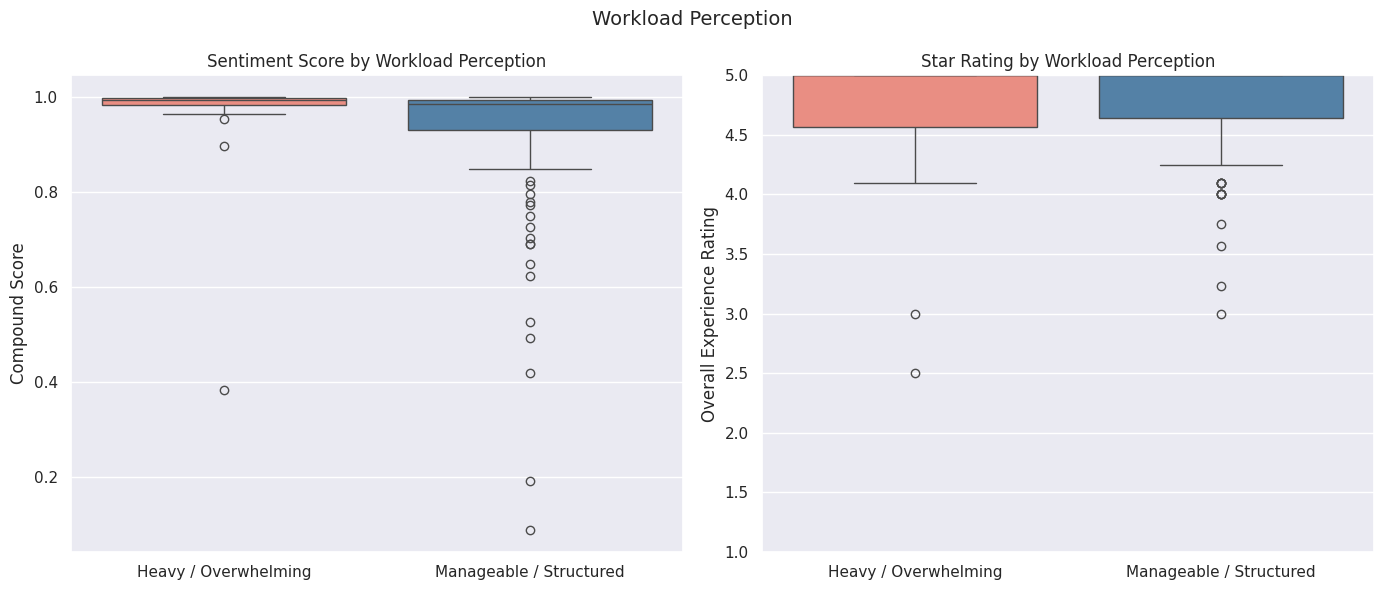

Saved: workload_perception.png


In [10]:
# Detect how students describe the workload — manageable or overwhelming.
# This is distinct from course pace (fast vs slow) and focuses specifically
# on the volume of work required. Understanding workload perception helps
# set accurate expectations during enrollment and informs curriculum design.

HEAVY_KEYWORDS = [
    "overwhelming", "too much", "too many", "exhausting", "burnout",
    "burn out", "overloaded", "too demanding", "drowning", "struggled",
    "very hard", "extremely difficult", "brutal",
]

MANAGEABLE_KEYWORDS = [
    "manageable", "well paced", "well-paced", "balanced", "reasonable",
    "not too much", "structured", "clear structure", "well structured",
    "well-structured", "organized", "organised",
]

df['workload_heavy']      = df['text_lower'].apply(
    lambda x: any(kw in str(x) for kw in HEAVY_KEYWORDS)
)
df['workload_manageable'] = df['text_lower'].apply(
    lambda x: any(kw in str(x) for kw in MANAGEABLE_KEYWORDS)
)

heavy_df      = df[df['workload_heavy']].copy()
manageable_df = df[df['workload_manageable']].copy()

print(f"Reviews describing heavy workload:      {len(heavy_df)}")
print(f"Reviews describing manageable workload: {len(manageable_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Workload Perception", fontsize=14)

workload_compare = pd.concat([
    heavy_df.assign(group='Heavy / Overwhelming'),
    manageable_df.assign(group='Manageable / Structured'),
])

sns.boxplot(
    data=workload_compare, x='group', y='sentiment_compound',
    hue='group', legend=False,
    ax=axes[0],
    palette={'Heavy / Overwhelming': 'salmon', 'Manageable / Structured': 'steelblue'}
)
axes[0].set_title("Sentiment Score by Workload Perception")
axes[0].set_xlabel("")
axes[0].set_ylabel("Compound Score")

sns.boxplot(
    data=workload_compare, x='group', y='overall_experience',
    hue='group', legend=False,
    ax=axes[1],
    palette={'Heavy / Overwhelming': 'salmon', 'Manageable / Structured': 'steelblue'}
)
axes[1].set_title("Star Rating by Workload Perception")
axes[1].set_xlabel("")
axes[1].set_ylabel("Overall Experience Rating")
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'workload_perception.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: workload_perception.png")

# Competition Mentions

Reviews containing unique selling point language: 218


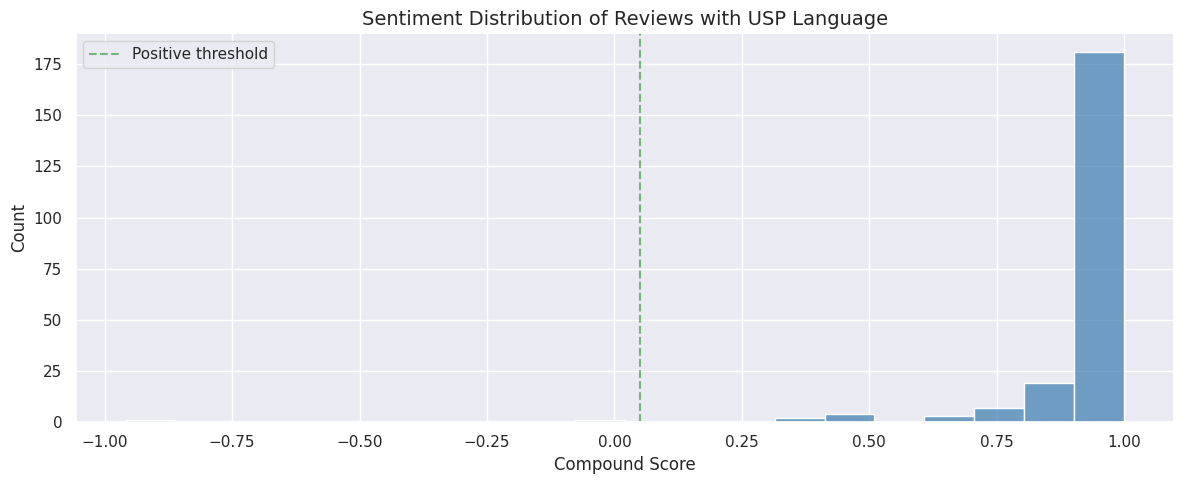

Saved: usp_detection.png

Top 10 USP reviews by sentiment score:

  Christian Goerke  | Data Science | Graduate | Sentiment: 1.00
  An EPIC Experience: After navigating through some tough personal times, the Data Science Bootcamp at WBS Coding School gave my life a new foundation and a new direction!From my first contact with the company, I felt welcomed, accepted and cared for. They gave a clear presentation of what was to come

  Christian Goerke | Data Science | <NA> | Sentiment: 1.00
  "An EPIC experience": After navigating through some tough personal times, the Data Science Bootcamp at WBS Coding School gave my life a new foundation and a new direction!From my first contact with the company, I felt welcomed, accepted and cared for. They gave a clear presentation of what was to co

  Luis Higuera  | Full-Stack Web & App | Manager | Sentiment: 1.00
  Amazing Learning Experience at WBS Coding School !: I have recently completed my Bootcamp on Full stack web Development at WBS Coding 

In [11]:
# Surface reviews that explicitly position WBS favourably against alternatives
# or mention something unique that no other school offers.
# These are the highest value marketing quotes because they do the competitive
# positioning work that generic positive reviews cannot.

USP_KEYWORDS = [
    "other schools", "compared to", "unlike other", "better than other",
    "only place", "only school", "best decision", "no regrets",
    "wish i found", "should have", "highly recommend", "tell everyone",
    "changed my life", "life changing", "life-changing", "transformed",
    "best investment", "best choice", "right choice",
]

df['mentions_usp'] = df['text_lower'].apply(
    lambda x: any(kw in str(x) for kw in USP_KEYWORDS)
)

usp_df = df[df['mentions_usp']].copy()
print(f"Reviews containing unique selling point language: {len(usp_df)}")

# Sort by compound score to surface the most positively framed USP reviews
usp_df = usp_df.sort_values('sentiment_compound', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(
    data=usp_df, x='sentiment_compound',
    bins=20, color='steelblue', ax=ax
)
ax.axvline(0.05, color='green', linestyle='--', alpha=0.5, label='Positive threshold')
ax.set_title("Sentiment Distribution of Reviews with USP Language", fontsize=14)
ax.set_xlabel("Compound Score")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'usp_detection.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: usp_detection.png")

print(f"\nTop 10 USP reviews by sentiment score:")
print(f"{'='*80}")
for i, row in usp_df.head(10).iterrows():
    print(f"\n  {row['author']} | {row['course']} | {row['role']} | Sentiment: {row['sentiment_compound']:.2f}")
    print(f"  {str(row['text_for_analysis'])[:300]}")
    print(f"{'='*80}")

# Sentiment vs. Data Source

Summary by batch:

  Google (scraped) (n=235)
    Mean compound: 0.668
    Pct positive:  90.6%

  CSV (prior intern) (n=536)
    Mean compound: 0.938
    Pct positive:  99.1%

  Newest batch (n=47)
    Mean compound: 0.960
    Pct positive:  100.0%


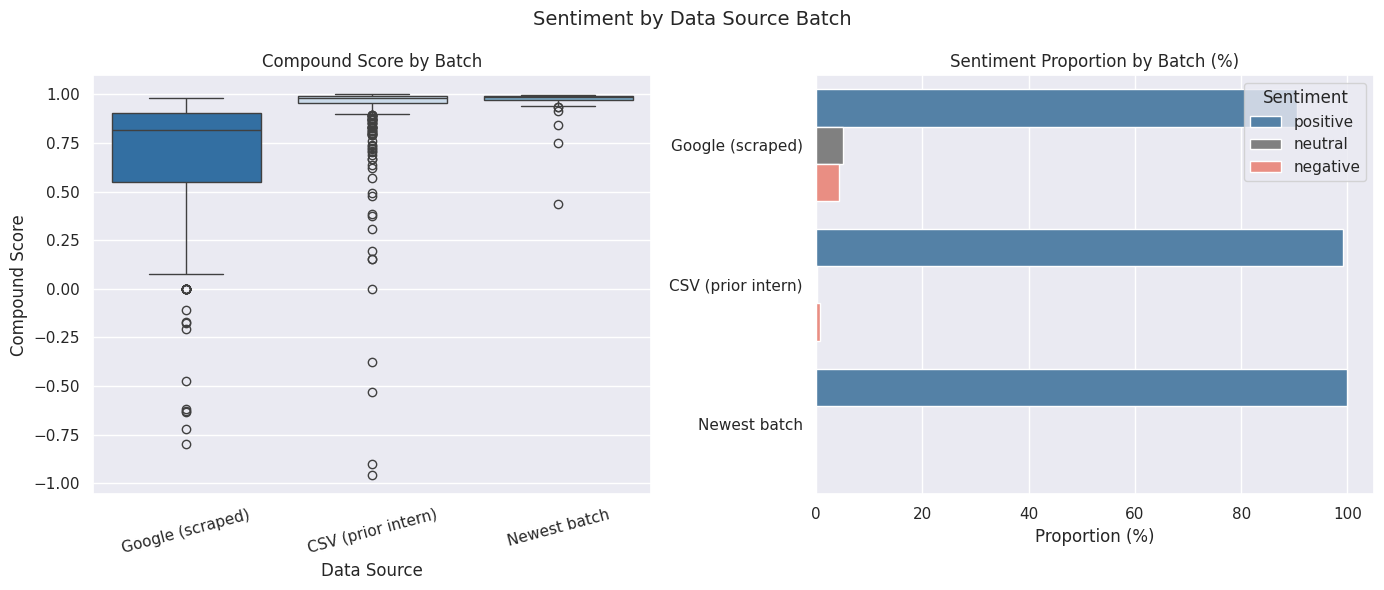

Saved: batch_comparison.png


In [12]:
# Compare sentiment across the three original data source batches.
# The newest batch (data_source=new) represents the most recent cohorts.
# If newer reviews score differently from older ones it may signal that
# the course experience has improved or declined over time.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Sentiment by Data Source Batch", fontsize=14)

batch_order = ['google', 'clean', 'new']
batch_labels = {'google': 'Google (scraped)', 'clean': 'CSV (prior intern)', 'new': 'Newest batch'}
df['batch_label'] = df['data_source'].map(batch_labels)
batch_label_order = [batch_labels[b] for b in batch_order]

sns.boxplot(
    data=df, x='batch_label', y='sentiment_compound',
    hue='batch_label', legend=False,
    order=batch_label_order,
    ax=axes[0], palette='Blues'
)
axes[0].set_title("Compound Score by Batch")
axes[0].set_xlabel("Data Source")
axes[0].set_ylabel("Compound Score")
axes[0].tick_params(axis='x', rotation=15)

label_data = df.groupby(['batch_label', 'sentiment_label']).size().reset_index(name='count')
total_data  = df.groupby('batch_label').size().reset_index(name='total')
label_data  = label_data.merge(total_data, on='batch_label')
label_data['proportion'] = (label_data['count'] / label_data['total'] * 100).round(1)
label_data['sentiment_label'] = pd.Categorical(
    label_data['sentiment_label'],
    categories=['positive', 'neutral', 'negative'], ordered=True
)
sns.barplot(
    data=label_data, x='proportion', y='batch_label',
    hue='sentiment_label', order=batch_label_order,
    palette={'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'},
    ax=axes[1]
)
axes[1].set_title("Sentiment Proportion by Batch (%)")
axes[1].set_xlabel("Proportion (%)")
axes[1].set_ylabel("")
axes[1].legend(title='Sentiment')

print("Summary by batch:")
for batch in batch_order:
    subset = df[df['data_source'] == batch]
    print(f"\n  {batch_labels[batch]} (n={len(subset)})")
    print(f"    Mean compound: {subset['sentiment_compound'].mean():.3f}")
    print(f"    Pct positive:  {(subset['sentiment_label'] == 'positive').mean() * 100:.1f}%")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'batch_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: batch_comparison.png")

# Flesch Score

Readability summary by sentiment:

  positive
    Mean readability:   53.3
    Median readability: 54.7

  neutral
    Mean readability:   57.1
    Median readability: 61.3

  negative
    Mean readability:   64.6
    Median readability: 68.3


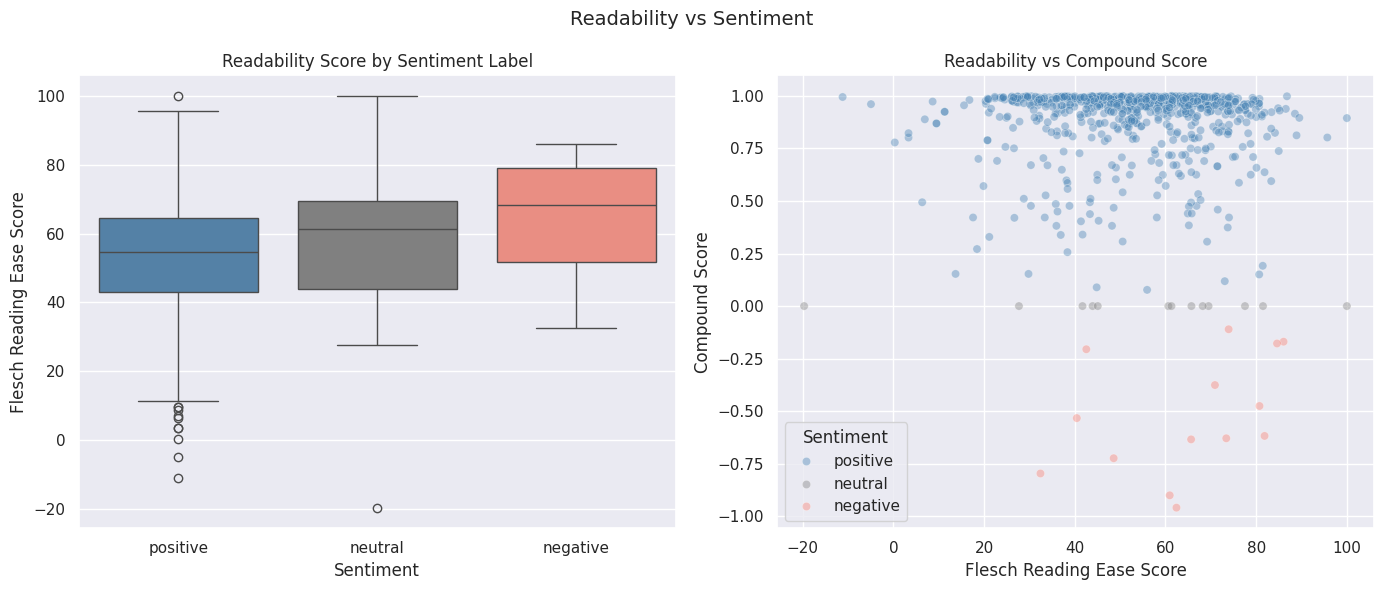

Saved: readability_vs_sentiment.png


In [13]:
# Calculate Flesch reading ease for every review and examine whether
# readability correlates with sentiment or rating.
# Higher Flesch score = easier to read (scale roughly 0 to 100).
# Negative reviews that are hard to read may reflect agitated writing.
# Highly readable positive reviews make the best marketing quotes.

df['readability_score'] = df['text_for_analysis'].apply(
    lambda x: textstat.flesch_reading_ease(str(x))
)

# Clamp extreme outliers for cleaner visualization
df['readability_clamped'] = df['readability_score'].clip(-20, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Readability vs Sentiment", fontsize=14)

palette     = {'positive': 'steelblue', 'neutral': 'grey', 'negative': 'salmon'}
label_order = ['positive', 'neutral', 'negative']

sns.boxplot(
    data=df, x='sentiment_label', y='readability_clamped',
    hue='sentiment_label', legend=False,
    order=label_order, palette=palette, ax=axes[0]
)
axes[0].set_title("Readability Score by Sentiment Label")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Flesch Reading Ease Score")

sns.scatterplot(
    data=df, x='readability_clamped', y='sentiment_compound',
    hue='sentiment_label', palette=palette,
    alpha=0.4, ax=axes[1]
)
axes[1].set_title("Readability vs Compound Score")
axes[1].set_xlabel("Flesch Reading Ease Score")
axes[1].set_ylabel("Compound Score")
axes[1].legend(title='Sentiment')

print("Readability summary by sentiment:")
for label in label_order:
    subset = df[df['sentiment_label'] == label]
    print(f"\n  {label}")
    print(f"    Mean readability:   {subset['readability_score'].mean():.1f}")
    print(f"    Median readability: {subset['readability_score'].median():.1f}")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'readability_vs_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: readability_vs_sentiment.png")

# Top and Bottom 5 Reviews

In [14]:
# Print the top 5 most positive and top 5 most negative reviews in full.
# These are selected purely by compound score so they represent the most
# emotionally charged reviews at each end of the spectrum.
# Reading them in full gives context that no chart can provide.

print("TOP 5 MOST POSITIVE REVIEWS")
print("=" * 80)

top_positive = df.nlargest(5, 'sentiment_compound')[
    ['author', 'course', 'role', 'source', 'overall_experience',
     'sentiment_compound', 'text_for_analysis']
].reset_index(drop=True)

for i, row in top_positive.iterrows():
    print(f"\n[{i+1}] {row['author']}")
    print(f"     Course:    {row['course']}")
    print(f"     Role:      {row['role']}")
    print(f"     Platform:  {row['source']}")
    print(f"     Rating:    {row['overall_experience']}")
    print(f"     Sentiment: {row['sentiment_compound']:.3f}")
    print(f"\n     {row['text_for_analysis']}")
    print("\n" + "=" * 80)

print("\n\nTOP 5 MOST NEGATIVE REVIEWS")
print("=" * 80)

top_negative = df.nsmallest(5, 'sentiment_compound')[
    ['author', 'course', 'role', 'source', 'overall_experience',
     'sentiment_compound', 'text_for_analysis']
].reset_index(drop=True)

for i, row in top_negative.iterrows():
    print(f"\n[{i+1}] {row['author']}")
    print(f"     Course:    {row['course']}")
    print(f"     Role:      {row['role']}")
    print(f"     Platform:  {row['source']}")
    print(f"     Rating:    {row['overall_experience']}")
    print(f"     Sentiment: {row['sentiment_compound']:.3f}")
    print(f"\n     {row['text_for_analysis']}")
    print("\n" + "=" * 80)

TOP 5 MOST POSITIVE REVIEWS

[1] Christian Goerke 
     Course:    Data Science
     Role:      Graduate
     Platform:  course_report
     Rating:    4.75
     Sentiment: 1.000

     An EPIC Experience: After navigating through some tough personal times, the Data Science Bootcamp at WBS Coding School gave my life a new foundation and a new direction!From my first contact with the company, I felt welcomed, accepted and cared for. They gave a clear presentation of what was to come and took the time to answer all my questions. In no way did the conversation feel rushed (unlike some experiences with other competitors). You'll quickly find that the people who work at WBS are open-min...After navigating through some tough personal times, the Data Science Bootcamp at WBS Coding School gave my life a new foundation and a new direction!From my first contact with the company, I felt welcomed, accepted and cared for. They gave a clear presentation of what was to come and took the time to answer 

## Chart

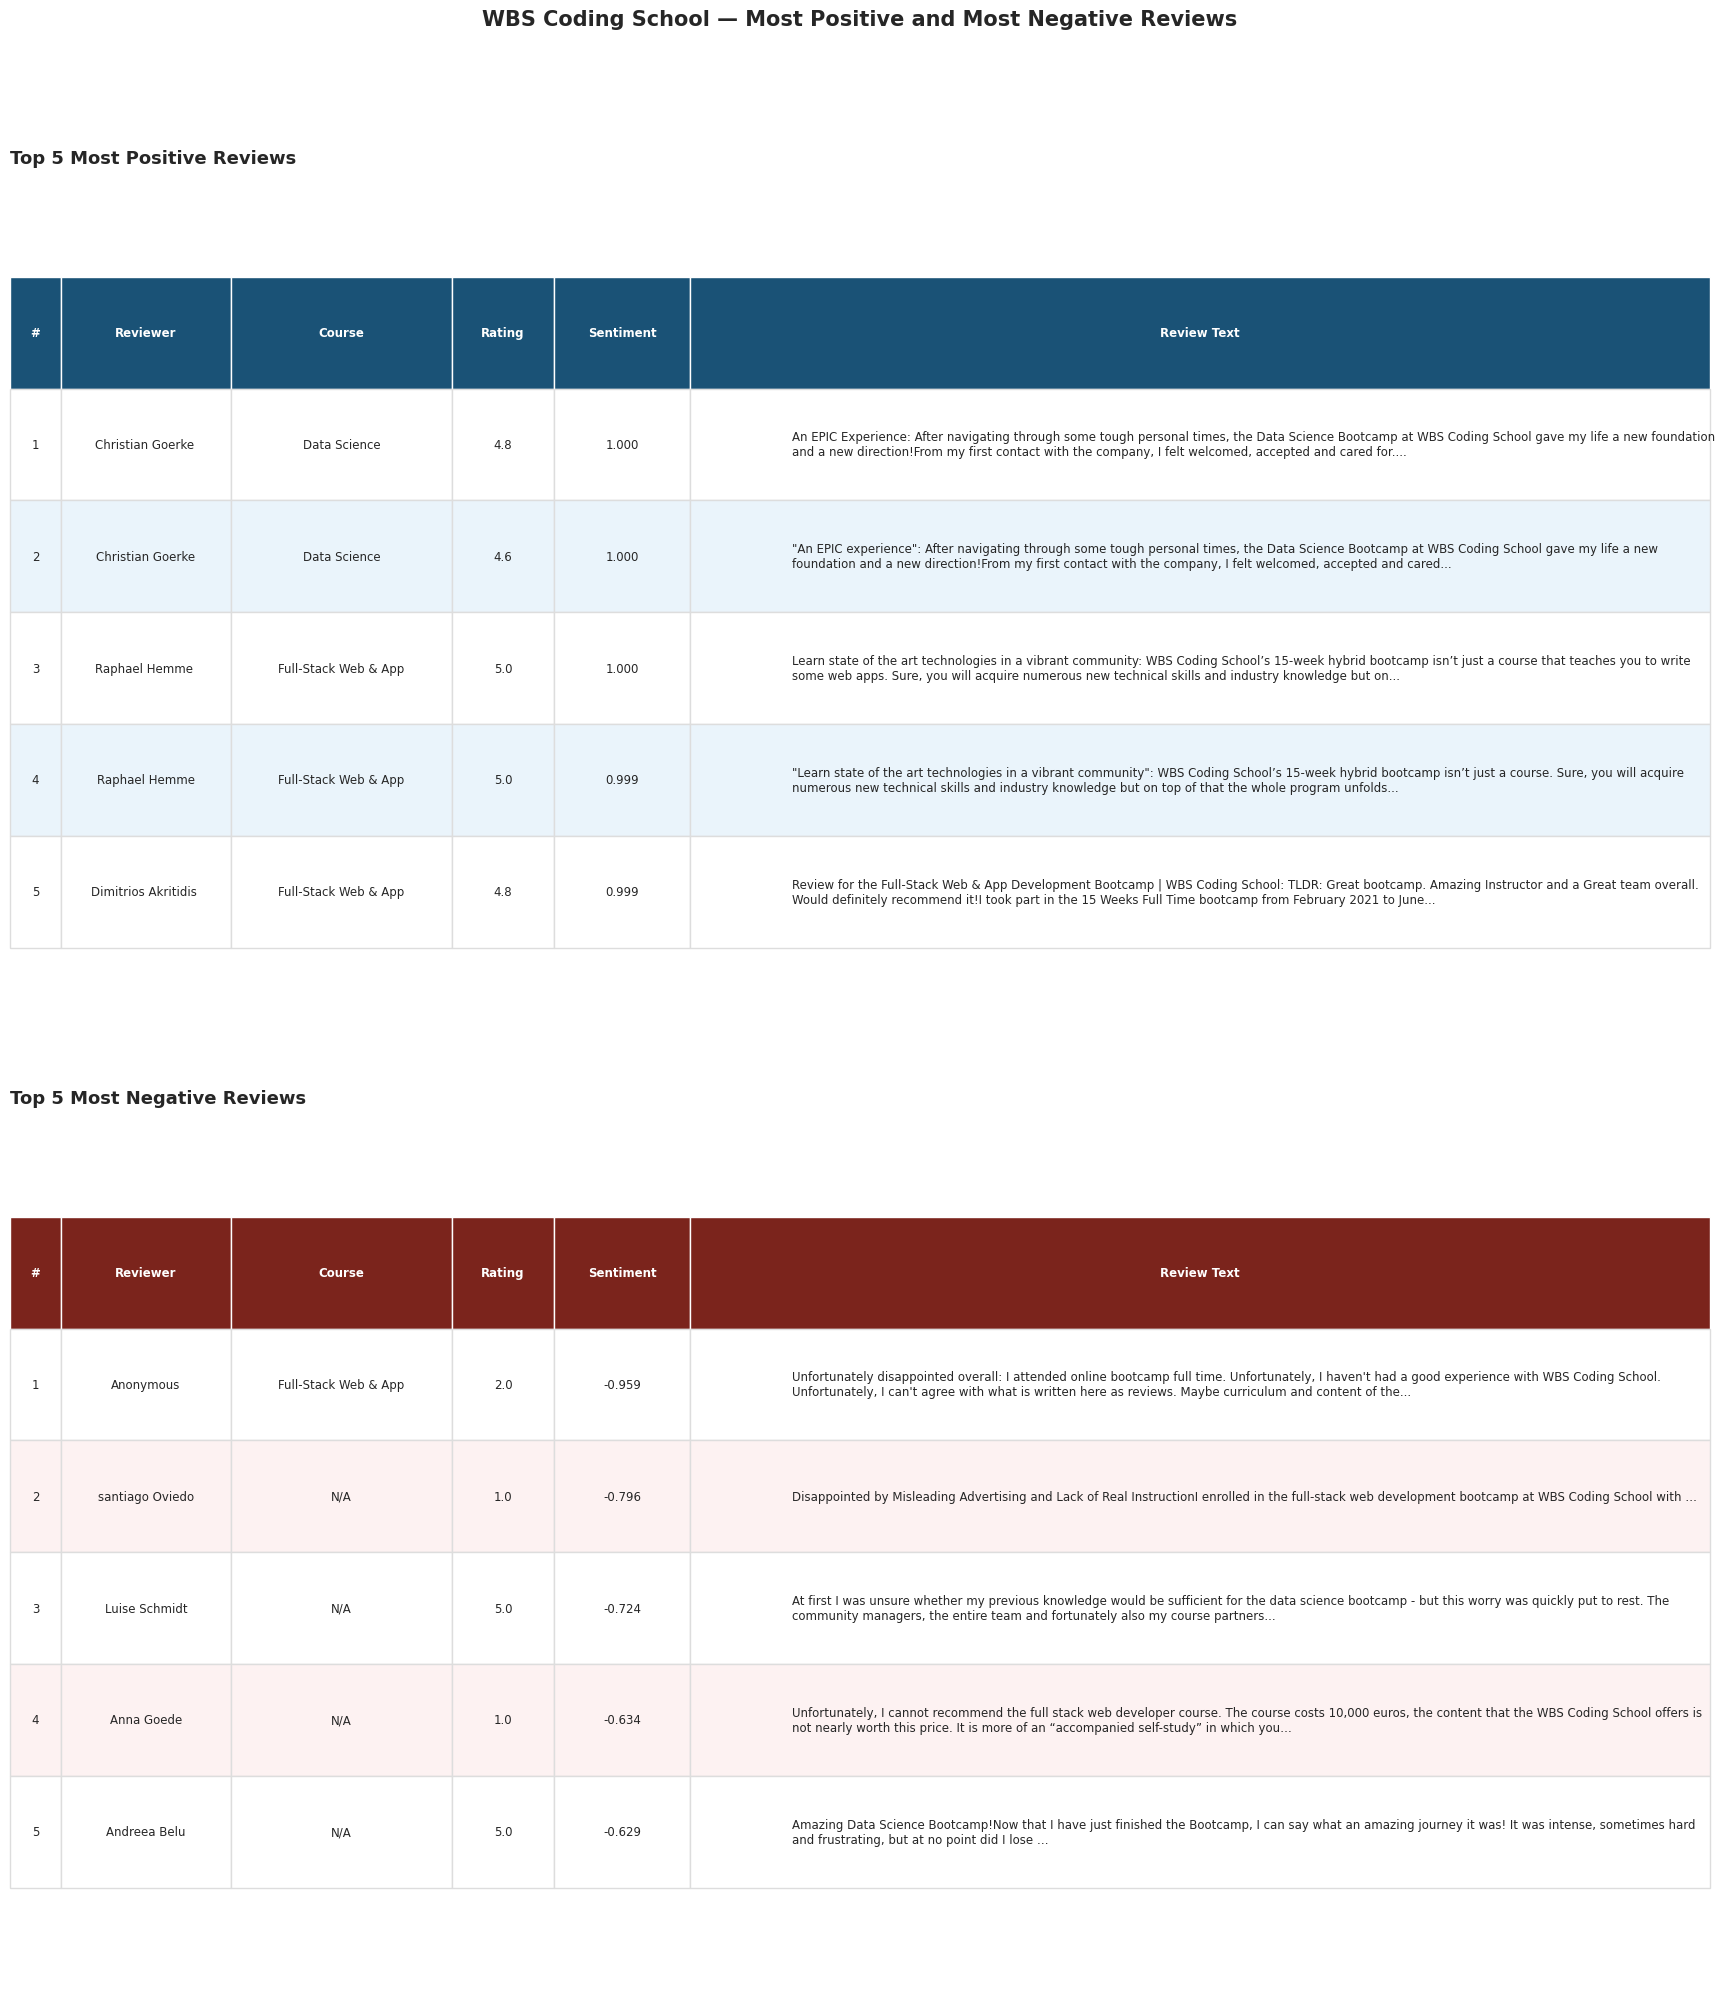

Saved: top_reviews_table.png
Saved: top_reviews.csv (10 rows)


In [15]:
# Display top 5 positive and negative reviews as a clean visual
# and export to CSV. Emojis are stripped before rendering since
# matplotlib cannot display them. Duplicates are removed by author
# so the same reviewer does not appear twice in the same list.

import unicodedata

def strip_emojis(text: str) -> str:
    """
    Remove emoji characters from a string.
    Keeps all standard Latin, punctuation, and accented characters.

    Args:
        text (str): Raw review text potentially containing emojis.

    Returns:
        str: Clean text with all emoji characters removed.
    """
    return "".join(
        c for c in str(text)
        if unicodedata.category(c) not in ('So', 'Cs', 'Co', 'Cn')
        and ord(c) < 0x10000
    )

def truncate_text(text: str, max_chars: int = 300) -> str:
    """
    Truncate text to a maximum character length without cutting mid-word.

    Args:
        text (str): Full review text.
        max_chars (int): Maximum characters before truncating.

    Returns:
        str: Truncated text ending with ellipsis if shortened.
    """
    text = strip_emojis(text)
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rsplit(' ', 1)[0] + "..."

# Get top 5 positive - deduplicate by author to avoid repeats
top_positive = (
    df.sort_values('sentiment_compound', ascending=False)
    .drop_duplicates(subset=['author'])
    .head(5)
    [['author', 'course', 'overall_experience', 'sentiment_compound', 'text_for_analysis']]
    .reset_index(drop=True)
)

# Get top 5 negative - deduplicate by author to avoid repeats
top_negative = (
    df.sort_values('sentiment_compound', ascending=True)
    .drop_duplicates(subset=['author'])
    .head(5)
    [['author', 'course', 'overall_experience', 'sentiment_compound', 'text_for_analysis']]
    .reset_index(drop=True)
)

# Build one figure with two clean tables
fig, axes = plt.subplots(2, 1, figsize=(18, 20))
fig.patch.set_facecolor('white')

col_labels = ['#', 'Reviewer', 'Course', 'Rating', 'Sentiment', 'Review Text']
col_widths = [0.03, 0.10, 0.13, 0.06, 0.08, 0.60]

for ax, subset, title, header_color, even_color in [
    (axes[0], top_positive, "Top 5 Most Positive Reviews", '#1a5276', '#eaf4fb'),
    (axes[1], top_negative, "Top 5 Most Negative Reviews", '#7b241c', '#fdf2f2'),
]:
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=16, loc='left')

    # Build clean table data with emoji stripped and text truncated
    table_data = []
    for i, row in subset.iterrows():
        table_data.append([
            str(i + 1),
            strip_emojis(str(row['author']))[:30],
            strip_emojis(str(row['course'])) if pd.notna(row['course']) else 'N/A',
            f"{row['overall_experience']:.1f}" if pd.notna(row['overall_experience']) else 'N/A',
            f"{row['sentiment_compound']:.3f}",
            truncate_text(str(row['text_for_analysis']), max_chars=250),
        ])

    table = ax.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc='left',
        loc='center',
        colWidths=col_widths,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1, 5.5)

    # Header row styling
    for j in range(len(col_labels)):
        cell = table[0, j]
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_edgecolor('white')

    # Data row styling with alternating row colors
    for i in range(1, 6):
        bg = even_color if i % 2 == 0 else 'white'
        for j in range(len(col_labels)):
            cell = table[i, j]
            cell.set_facecolor(bg)
            cell.set_edgecolor('#dddddd')
            # Left-align text in review column, center elsewhere
            cell.set_text_props(
                ha='left' if j == 5 else 'center',
                wrap=True
            )

plt.suptitle(
    "WBS Coding School — Most Positive and Most Negative Reviews",
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout(pad=3.0)
plt.savefig(os.path.join(CHARTS_DIR, 'top_reviews_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_reviews_table.png")

# Export to CSV with group column and clean text
top_positive_export = top_positive.copy()
top_positive_export.insert(0, 'group', 'Top 5 Positive')
top_negative_export = top_negative.copy()
top_negative_export.insert(0, 'group', 'Top 5 Negative')

top_reviews_export = pd.concat(
    [top_positive_export, top_negative_export], ignore_index=True
).rename(columns={
    'author':             'Reviewer',
    'course':             'Course',
    'overall_experience': 'Rating',
    'sentiment_compound': 'Sentiment Score',
    'text_for_analysis':  'Review Text',
})

csv_path = os.path.join(EXPORT_DIR, 'top_reviews.csv')
top_reviews_export.to_csv(csv_path, index=False)
print(f"Saved: top_reviews.csv ({len(top_reviews_export)} rows)")

# Exports

In [16]:
# Update the summary CSV to include top review findings.
# Reloads the existing summary and appends new rows rather than
# rebuilding it from scratch so nothing already saved is lost.

additional_summary = {
    "most_positive_reviewer":          [top_positive.iloc[0]['author']],
    "most_positive_reviewer_score":    [top_positive.iloc[0]['sentiment_compound']],
    "most_positive_reviewer_course":   [top_positive.iloc[0]['course']],
    "most_negative_reviewer":          [top_negative.iloc[0]['author']],
    "most_negative_reviewer_score":    [top_negative.iloc[0]['sentiment_compound']],
    "most_negative_reviewer_course":   [top_negative.iloc[0]['course']],
    "top_reviews_csv":                 [csv_path],
}

additional_df = pd.DataFrame(additional_summary).T.reset_index()
additional_df.columns = ['metric', 'value']

# Load the existing summary and append the new rows
summary_path = os.path.join(EXPORT_DIR, 'student_experience_summary.csv')
existing_summary = pd.read_csv(summary_path)
updated_summary  = pd.concat([existing_summary, additional_df], ignore_index=True)
updated_summary.to_csv(summary_path, index=False)

print("Summary updated.")
print(f"\nFull updated summary:")
print(updated_summary.to_string(index=False))

Summary updated.

Full updated summary:
                       metric                                                                                               value
       total_reviews_analyzed                                                                                                 818
    reviews_mentioning_hiring                                                                                                  17
reviews_exceeded_expectations                                                                                                  44
           reviews_fell_short                                                                                                  15
       reviews_heavy_workload                                                                                                  26
  reviews_manageable_workload                                                                                                 152
    reviews_with_usp_language                     

In [17]:
import pandas as pd
from pathlib import Path

DASHBOARD_PATH  = '/content/drive/Shareddrives/essentis_intern_drive/data/processed/dashboard_master.csv'
EXP_EXPORT_DIR  = '/content/drive/Shareddrives/essentis_intern_drive/charts/student_experience/exports'

dashboard_df = pd.read_csv(DASHBOARD_PATH)
print(f"Loaded dashboard_master.csv: {dashboard_df.shape}")

EXPERIENCE_COLS = [
    'mentions_hiring', 'mentions_usp', 'expectation_exceeded',
    'expectation_fell_short', 'workload_heavy', 'workload_manageable',
    'readability_score', 'review_length_chars', 'review_length_words',
]
available_cols = [c for c in EXPERIENCE_COLS if c in df.columns]

merge_df = df[['author', 'review_text'] + available_cols].copy()

dashboard_df = dashboard_df.drop(columns=available_cols, errors='ignore')
dashboard_df = dashboard_df.merge(
    merge_df,
    on=['author', 'review_text'],
    how='left'
)

print(f"Updated shape: {dashboard_df.shape}")
dashboard_df.to_csv(DASHBOARD_PATH, index=False)
print(f"Saved: dashboard_master.csv")

os.makedirs(EXP_EXPORT_DIR, exist_ok=True)

summary = {
    "total_reviews_analyzed":          [len(df)],
    "reviews_mentioning_hiring":       [df['mentions_hiring'].sum()],
    "reviews_exceeded_expectations":   [df['expectation_exceeded'].sum()],
    "reviews_fell_short":              [df['expectation_fell_short'].sum()],
    "reviews_heavy_workload":          [df['workload_heavy'].sum()],
    "reviews_manageable_workload":     [df['workload_manageable'].sum()],
    "reviews_with_usp_language":       [df['mentions_usp'].sum()],
    "top_enrollment_motivation":       [motivation_df.iloc[0]['motivation']],
    "avg_readability_positive":        [round(df[df['sentiment_label'] == 'positive']['readability_score'].mean(), 1)],
    "avg_readability_negative":        [round(df[df['sentiment_label'] == 'negative']['readability_score'].mean(), 1)],
    "most_positive_platform":          [avg_source.iloc[0]['source']],
    "least_positive_platform":         [avg_source.iloc[-1]['source']],
    "most_positive_reviewer":          [top_positive.iloc[0]['author']],
    "most_negative_reviewer":          [top_negative.iloc[0]['author']],
}
summary_df = pd.DataFrame(summary).T.reset_index()
summary_df.columns = ['metric', 'value']
summary_df.to_csv(os.path.join(EXP_EXPORT_DIR, 'student_experience_summary.csv'), index=False)

top_positive_export = top_positive.copy()
top_positive_export.insert(0, 'group', 'Top 5 Positive')
top_negative_export = top_negative.copy()
top_negative_export.insert(0, 'group', 'Top 5 Negative')
pd.concat([top_positive_export, top_negative_export], ignore_index=True).rename(columns={
    'author': 'Reviewer', 'course': 'Course',
    'overall_experience': 'Rating', 'sentiment_compound': 'Sentiment Score',
    'text_for_analysis': 'Review Text',
}).to_csv(os.path.join(EXP_EXPORT_DIR, 'top_reviews.csv'), index=False)

print(f"\nAlso saved: student_experience_summary.csv, top_reviews.csv")

Loaded dashboard_master.csv: (839, 58)
Updated shape: (839, 59)
Saved: dashboard_master.csv

Also saved: student_experience_summary.csv, top_reviews.csv


In [18]:
# Run this in any notebook where df is loaded and sentiment scores exist.
# Copy and paste the full output into the chat.

import pandas as pd
import numpy as np

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Total reviews: {len(df)}")
print(f"Date range: {df['review_date'].min().date()} to {df['review_date'].max().date()}")
print(f"\nBy data source:")
print(df['data_source'].value_counts().to_string())
print(f"\nBy course:")
print(df['course'].value_counts(dropna=False).to_string())
print(f"\nBy role:")
print(df['role'].value_counts(dropna=False).to_string())
print(f"\nBy course format:")
print(df['course_format'].value_counts(dropna=False).to_string())

print("\n" + "=" * 80)
print("RATINGS")
print("=" * 80)
print(f"\nOverall experience:")
print(df['overall_experience'].describe().round(3).to_string())
print(f"\nAvg overall_experience by course:")
print(df.groupby('course')['overall_experience'].agg(['mean','count']).round(3).to_string())
print(f"\nAvg overall_experience by role:")
print(df.groupby('role')['overall_experience'].agg(['mean','count']).round(3).to_string())
print(f"\nAvg overall_experience by course_format:")
print(df.groupby('course_format')['overall_experience'].agg(['mean','count']).round(3).to_string())
print(f"\nAvg ratings by dimension:")
for col in ['review', 'instructors', 'curriculum', 'job_assistance']:
    print(f"  {col}: {df[col].mean():.3f} (n={df[col].notna().sum()})")
print(f"\nAvg overall_experience by year:")
# Add review_year temporarily for this analysis
df['review_year'] = df['review_date'].dt.year

print("Avg overall_experience by year:")
print(df.groupby('review_year')['overall_experience'].agg(['mean','count']).round(3).to_string())

print("\n" + "=" * 80)
print("SENTIMENT")
print("=" * 80)
print(f"\nSentiment label breakdown:")
print(df['sentiment_label'].value_counts().to_string())
print(f"\nAvg compound score: {df['sentiment_compound'].mean():.3f}")
print(f"Median compound score: {df['sentiment_compound'].median():.3f}")
print(f"\nAvg sentiment by course:")
print(df.groupby('course')['sentiment_compound'].agg(['mean','count']).round(3).to_string())
print(f"\nAvg sentiment by role:")
print(df.groupby('role')['sentiment_compound'].agg(['mean','count']).round(3).to_string())
print(f"\nAvg sentiment by source:")
print(df.groupby('source')['sentiment_compound'].agg(['mean','count']).round(3).to_string())
print(f"\nAvg sentiment by year:")
print(df.groupby('review_year')['sentiment_compound'].agg(['mean','count']).round(3).to_string())
print(f"\nSentiment vs rating gap:")
print(f"  High rating (>=4) but negative sentiment: {len(df[(df['overall_experience']>=4) & (df['sentiment_label']=='negative')])}")
print(f"  Low rating (<=2) but positive sentiment:  {len(df[(df['overall_experience']<=2) & (df['sentiment_label']=='positive')])}")

print("\n" + "=" * 80)
print("ASPECTS")
print("=" * 80)
aspect_cols = [c for c in df.columns if c.startswith('aspect_')]
for col in aspect_cols:
    pct = df[col].sum() / len(df) * 100
    print(f"  {col.replace('aspect_',''):25s} {df[col].sum():4d} mentions  ({pct:.1f}%)")

print("\n" + "=" * 80)
print("EXPERIENCE FLAGS")
print("=" * 80)
flag_cols = ['mentions_hiring','mentions_usp','expectation_exceeded',
             'expectation_fell_short','workload_heavy','workload_manageable']
for col in flag_cols:
    if col in df.columns:
        pct = df[col].sum() / len(df) * 100
        print(f"  {col:30s} {df[col].sum():4d}  ({pct:.1f}%)")

print("\n" + "=" * 80)
print("MOTIVATIONS")
print("=" * 80)
mot_cols = [c for c in df.columns if c.startswith('motivation_')]
for col in mot_cols:
    pct = df[col].sum() / len(df) * 100
    print(f"  {col.replace('motivation_',''):25s} {df[col].sum():4d} mentions  ({pct:.1f}%)")

print("\n" + "=" * 80)
print("SEMANTIC THEMES")
print("=" * 80)
if 'semantic_theme' in df.columns:
    print(df['semantic_theme'].value_counts(dropna=False).to_string())
    print(f"\nAvg semantic score by theme:")
    print(df.groupby('semantic_theme')['semantic_best_score'].mean().round(3).to_string())
    print(f"\nTop matched queries:")
    print(df['semantic_best_query'].value_counts().head(10).to_string())

print("\n" + "=" * 80)
print("VERIFIED vs UNVERIFIED")
print("=" * 80)
if 'verified_label' in df.columns:
    print(df.groupby('verified_label')['sentiment_compound'].agg(['mean','count']).round(3).to_string())
    print(f"\nAvg rating by verification:")
    print(df.groupby('verified_label')['overall_experience'].agg(['mean','count']).round(3).to_string())

print("\n" + "=" * 80)
print("TOP 5 MOST POSITIVE REVIEWS")
print("=" * 80)
top_pos = df.sort_values('sentiment_compound', ascending=False).drop_duplicates(subset=['author']).head(5)
for _, row in top_pos.iterrows():
    print(f"\n  {row['author']} | {row['course']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.3f}")
    print(f"  {str(row['text_for_analysis'])[:300]}")

print("\n" + "=" * 80)
print("TOP 5 MOST NEGATIVE REVIEWS")
print("=" * 80)
top_neg = df.sort_values('sentiment_compound', ascending=True).drop_duplicates(subset=['author']).head(5)
for _, row in top_neg.iterrows():
    print(f"\n  {row['author']} | {row['course']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.3f}")
    print(f"  {str(row['text_for_analysis'])[:300]}")

print("\n" + "=" * 80)
print("NOTABLE OUTLIERS")
print("=" * 80)
gap = df.dropna(subset=['overall_experience','sentiment_compound'])
high_rate_neg = gap[(gap['overall_experience']>=4) & (gap['sentiment_label']=='negative')]
low_rate_pos  = gap[(gap['overall_experience']<=2) & (gap['sentiment_label']=='positive')]
print(f"\nHigh rating (>=4) but negative sentiment ({len(high_rate_neg)} reviews):")
for _, row in high_rate_neg.head(3).iterrows():
    print(f"  {row['author']} | {row['course']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.3f}")
    print(f"  {str(row['text_for_analysis'])[:200]}")
print(f"\nLow rating (<=2) but positive sentiment ({len(low_rate_pos)} reviews):")
for _, row in low_rate_pos.head(3).iterrows():
    print(f"  {row['author']} | {row['course']} | Rating: {row['overall_experience']} | Sentiment: {row['sentiment_compound']:.3f}")
    print(f"  {str(row['text_for_analysis'])[:200]}")

DATASET OVERVIEW
Total reviews: 818
Date range: 2019-02-03 to 2025-12-17

By data source:
data_source
clean     536
google    235
new        47

By course:
course
Full-Stack Web & App          314
<NA>                          280
Data Science                  182
Product Design                 24
Marketing Analytics            16
Full-Stack PHP Development      2

By role:
role
<NA>            552
Graduate        172
Developer        35
Student          30
Data Science     10
Manager           6
Designer          5
Other             5
Applicant         3

By course format:
course_format
full-time    500
<NA>         302
part-time     16

RATINGS

Overall experience:
count    818.000
mean       4.782
std        0.498
min        1.000
25%        4.750
50%        5.000
75%        5.000
max        5.000

Avg overall_experience by course:
                             mean  count
course                                  
Data Science                4.776    182
Full-Stack PHP Development  4.